# Exploratory Data Analysis (EDA)

### Load cleaned dataset

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../Dataset/cleaned_dataset.csv")
df.head()

,T_feed,P_feed,z_benzene,reflux_ratio,stages,feed_stage,bottoms_flow,xD,xB,QC,QR
0,121.863389,1.165677,0.257171,4.146966,13.0,4.0,50.408283,0.732362,0.015341,363.691448,-373.005068
1,89.459707,1.638306,0.364948,4.224859,27.0,3.0,52.202497,0.763635,0.017705,508.301600,-306.094604
2,115.172163,1.843883,0.626730,4.901157,29.0,18.0,46.260664,0.987195,0.126703,636.041981,-250.296414
3,101.483985,1.810678,0.452148,3.934965,18.0,9.0,77.320856,0.782563,0.019401,626.130267,-251.510105
4,120.572133,1.436241,0.608326,3.059427,21.0,10.0,59.541746,0.978757,0.095971,634.435014,-250.295981


### Dataset Overview

In [12]:
df.shape

(600, 11)

In [13]:
df.describe()

,T_feed,P_feed,z_benzene,reflux_ratio,stages,feed_stage,bottoms_flow,xD,xB,QC,QR
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,105.024063,1.499723,0.498629,3.134418,19.433333,13.350000,49.233185,0.858063,0.108458,568.351921,-280.191650
std,14.422435,0.288249,0.166470,1.089100,5.742576,6.294193,17.062996,0.115469,0.143348,97.815244,43.746449
min,80.495609,1.000853,0.201041,1.203401,10.000000,3.000000,20.063758,0.589392,0.008601,360.899024,-373.016730
25%,93.209879,1.237702,0.360366,2.214848,14.000000,8.000000,34.923598,0.762626,0.017621,502.047090,-308.991786
50%,104.602811,1.494808,0.491662,3.067021,19.000000,14.000000,48.495775,0.841655,0.026623,627.950532,-251.174925
75%,117.631200,1.755974,0.633634,4.117984,24.000000,19.000000,64.241614,0.989210,0.140084,636.672964,-250.292853
max,129.860537,1.997185,0.799478,4.998750,29.000000,24.000000,79.996616,0.998806,0.527270,649.162873,-248.803286


### Correlation Matrix

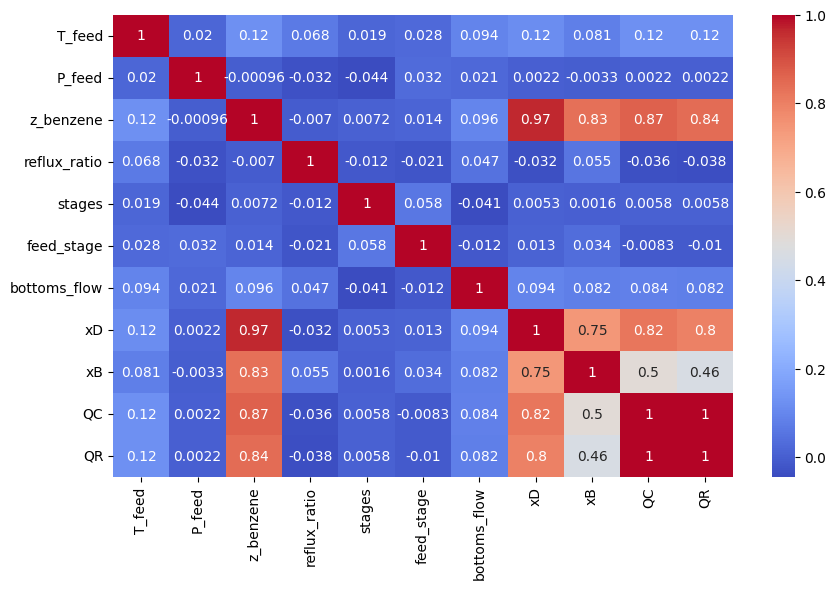

In [14]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

### Reflux ratio vs distillate purity

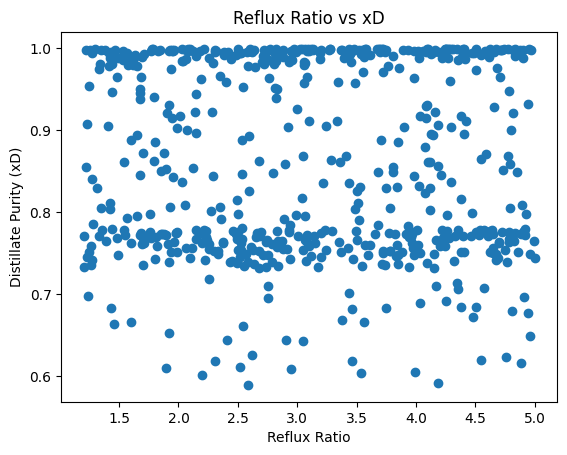

In [15]:
plt.scatter(df["reflux_ratio"], df["xD"])
plt.xlabel("Reflux Ratio")
plt.ylabel("Distillate Purity (xD)")
plt.title("Reflux Ratio vs xD")
plt.show()

### Feed composition vs xD

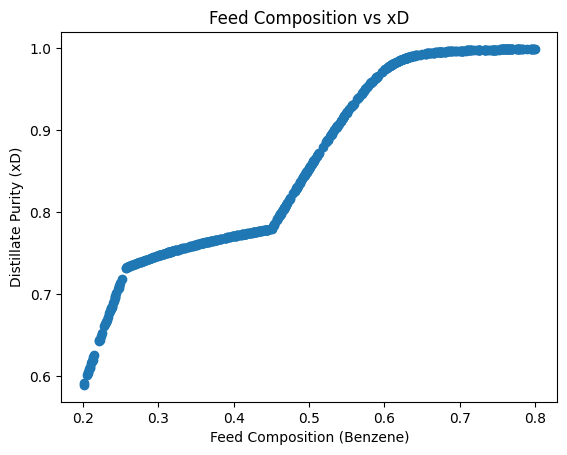

In [16]:
plt.scatter(df["z_benzene"], df["xD"])
plt.xlabel("Feed Composition (Benzene)")
plt.ylabel("Distillate Purity (xD)")
plt.title("Feed Composition vs xD")
plt.show()

### Reflux vs energy

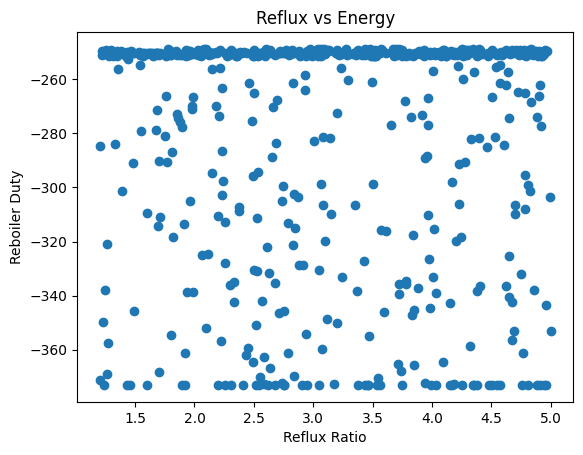

In [17]:
plt.scatter(df["reflux_ratio"], df["QR"])
plt.xlabel("Reflux Ratio")
plt.ylabel("Reboiler Duty")
plt.title("Reflux vs Energy")
plt.show()

### Feature Selection

In [18]:
X = df[["T_feed", "P_feed", "z_benzene", "reflux_ratio"]]
y_xD = df["xD"]
y_xB = df["xB"]
y_QC = df["QC"]
y_QR = df["QR"]

#### Train-test split

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_xD, test_size=0.2, random_state=42)